In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import pandas as pd

zip_file_path = '/content/drive/MyDrive/Developers Hub/Mall customer.zip'
extraction_path = '/tmp/mall_customer_data/'

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

# Assuming the unzipped file is a CSV and is the only file or has a common name like 'Mall_Customers.csv'
# We need to find the actual CSV file name after extraction
import os
csv_files = [f for f in os.listdir(extraction_path) if f.endswith('.csv')]

if csv_files:
    csv_file_name = csv_files[0] # Take the first CSV file found
    data_path = os.path.join(extraction_path, csv_file_name)
    df = pd.read_csv(data_path)
    print(f'Successfully loaded {csv_file_name} into a DataFrame.')
    display(df.head())
else:
    print('No CSV file found in the unzipped directory.')
    print(f'Contents of {extraction_path}: {os.listdir(extraction_path)}')


Successfully loaded Mall_Customers.csv into a DataFrame.


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 1. Exploratory Data Analysis (EDA)

In [3]:
print("DataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe())

print("\nMissing Values:")
display(df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Descriptive Statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000



Missing Values:


,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


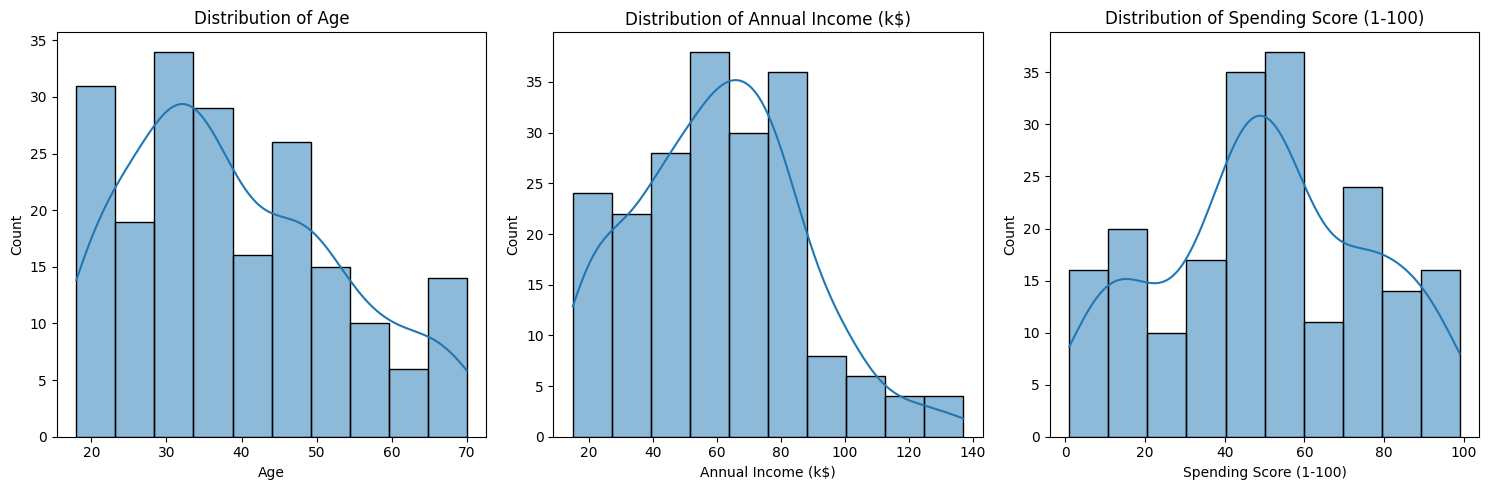

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['Age'], bins=10, kde=True)
plt.title('Distribution of Age')

plt.subplot(1, 3, 2)
sns.histplot(df['Annual Income (k$)'], bins=10, kde=True)
plt.title('Distribution of Annual Income (k$)')

plt.subplot(1, 3, 3)
sns.histplot(df['Spending Score (1-100)'], bins=10, kde=True)
plt.title('Distribution of Spending Score (1-100)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_5323/4110916853.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Genre', data=df, palette='viridis')


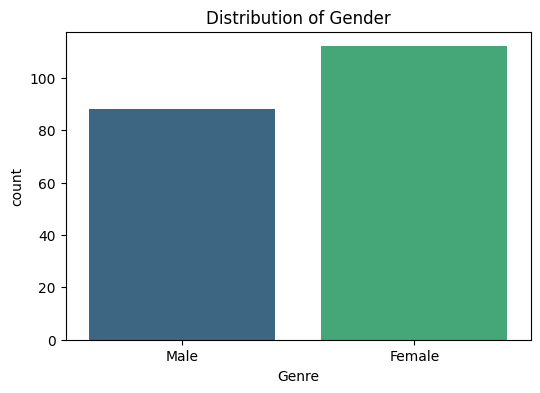

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Genre', data=df, palette='viridis')
plt.title('Distribution of Gender')
plt.show()

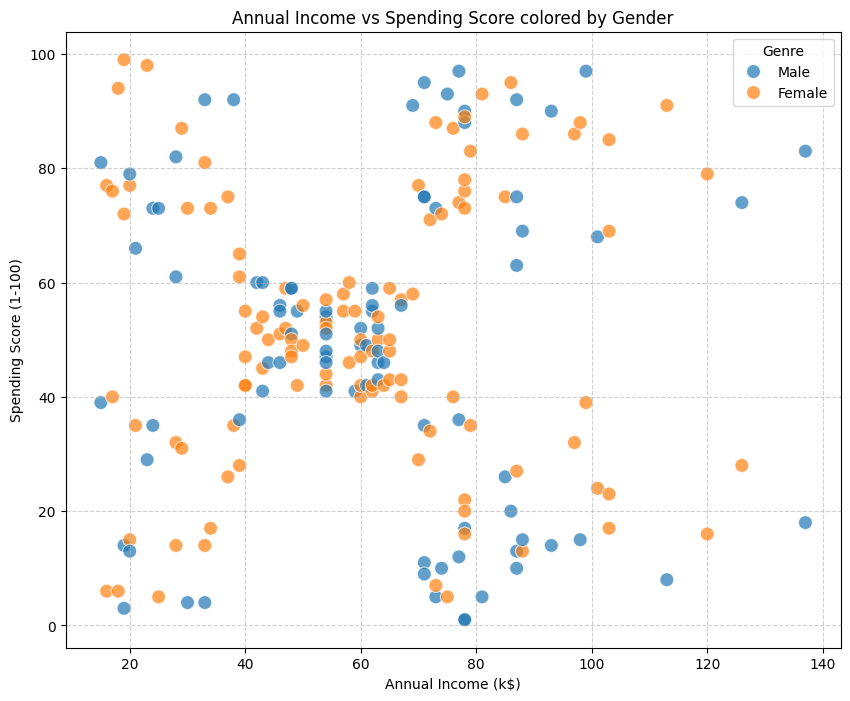

In [6]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Genre', data=df, s=100, alpha=0.7)
plt.title('Annual Income vs Spending Score colored by Gender')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 2. K-Means Clustering

### Selecting features for clustering and determining optimal number of clusters (Elbow Method)

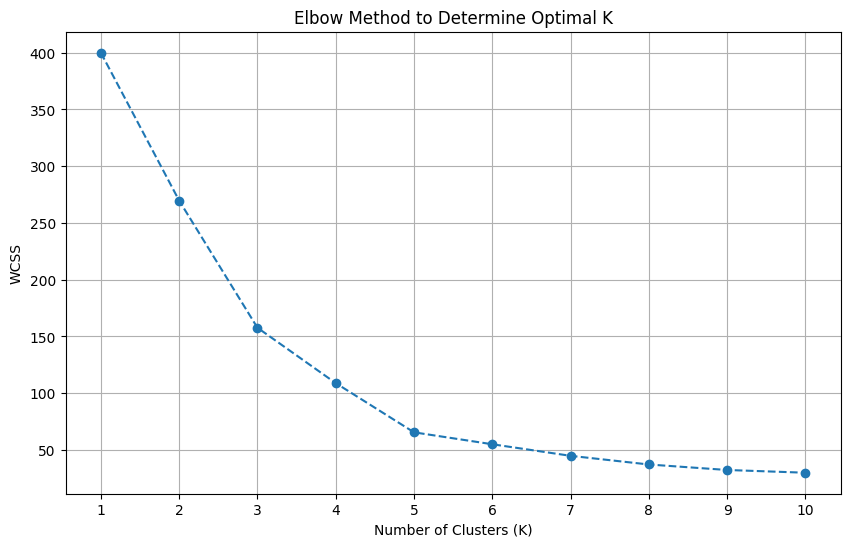

In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features for clustering: Annual Income and Spending Score
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale the features (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine optimal number of clusters using the Elbow Method
wcss = [] # Within-cluster sum of squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

### Applying K-Means Clustering and Visualizing Clusters

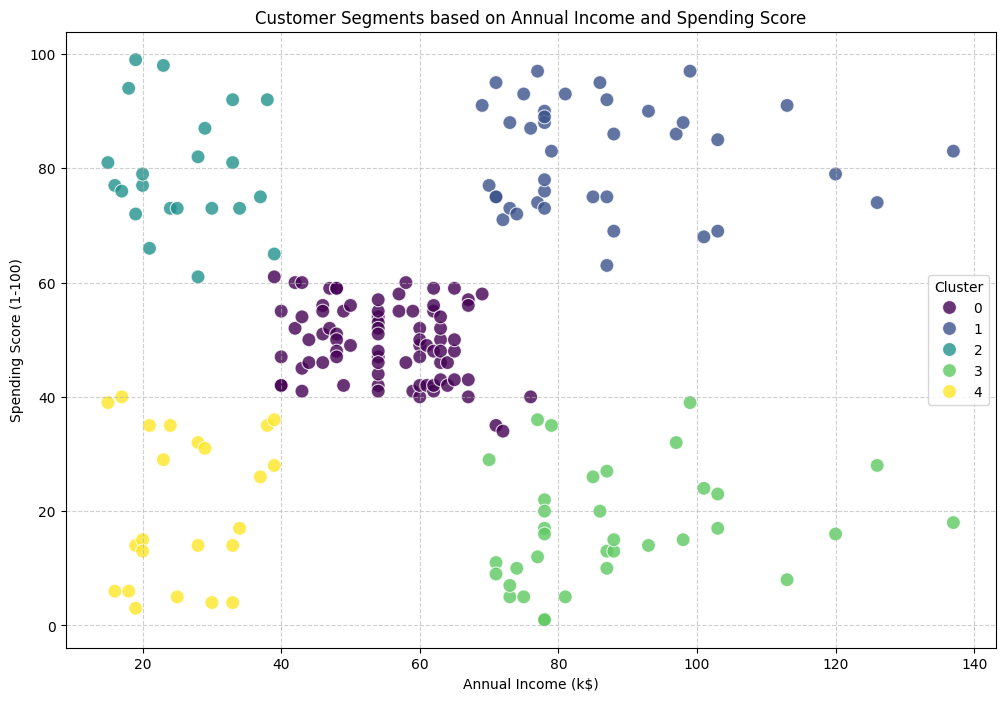

Cluster distribution:


,count
Cluster,
0,81
1,39
2,22
3,35
4,23


In [8]:
# Apply K-Means with the chosen number of clusters (e.g., 5)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original DataFrame
df['Cluster'] = clusters

# Visualize the clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='viridis',
    s=100,
    alpha=0.8,
    edgecolor='w'
)
plt.title('Customer Segments based on Annual Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster')
plt.show()

print("Cluster distribution:")
display(df['Cluster'].value_counts().sort_index())

### Characteristics of Each Cluster

In [9]:
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Genre']].agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Genre': lambda x: x.mode()[0] if not x.empty else 'N/A' # Get most frequent gender
}).round(2)

print("Average characteristics of each cluster:")
display(cluster_summary)

Average characteristics of each cluster:


,Age,Annual Income (k$),Spending Score (1-100),Genre
Cluster,,,,
0,42.72,55.30,49.52,Female
1,32.69,86.54,82.13,Female
2,25.27,25.73,79.36,Female
3,41.11,88.20,17.11,Male
4,45.22,26.30,20.91,Female


## 3. Suggest Relevant Marketing Strategies

In [10]:
print("### Marketing Strategies for Each Cluster:")
print("\n**Cluster 0 (High Income, Low Spending - 'Careful Spenders'):**")
print("- **Characteristics:** These customers have high annual incomes but low spending scores. They are likely affluent but budget-conscious or have other priorities.")
print("- **Strategy:** Focus on value for money, exclusive premium offers, loyalty programs, and highlighting long-term benefits or investment-worthy products. Personalized recommendations for high-end, durable goods. Avoid pushing impulse buys.")

print("\n**Cluster 1 (Low Income, High Spending - 'Impulse Buyers/High Spenders'):**")
print("- **Characteristics:** These customers have low annual incomes but high spending scores. They might be impulse buyers, heavily influenced by trends, or seeking aspirational products.")
print("- **Strategy:** Offer attractive discounts, payment plans, easy credit options, and trendy, affordable products. Create a sense of urgency with flash sales and limited-time offers. Leverage social media marketing and influencers.")

print("\n**Cluster 2 (High Income, High Spending - 'Target Customers/Big Spenders'):**")
print("- **Characteristics:** This is the ideal customer segment with high annual incomes and high spending scores. They are likely to be early adopters, trendsetters, and value quality and experience.")
print("- **Strategy:** Prioritize these customers with VIP treatment, exclusive previews of new collections, personalized shopping experiences, and premium services. Focus on building brand loyalty through exceptional customer service and luxury offerings.")

print("\n**Cluster 3 (Low Income, Low Spending - 'Budget-Conscious/Frugal'):**")
print("- **Characteristics:** Customers in this segment have both low annual income and low spending scores. They are likely very price-sensitive and only buy essentials.")
print("- **Strategy:** Offer budget-friendly products, essential items at competitive prices, and bulk discounts. Focus on practicality and necessity. Clear communication on cost savings and value. Avoid luxury marketing.")

print("\n**Cluster 4 (Mid Income, Mid Spending - 'Average/Mainstream'):**")
print("- **Characteristics:** This is a large, balanced segment with moderate incomes and moderate spending scores. They represent the general customer base.")
print("- **Strategy:** A broad marketing approach with a mix of promotions, new product introductions, and standard loyalty programs. Focus on convenience, good quality at reasonable prices, and a wide variety of choices. Use general advertising campaigns.")

### Marketing Strategies for Each Cluster:

**Cluster 0 (High Income, Low Spending - 'Careful Spenders'):**
- **Characteristics:** These customers have high annual incomes but low spending scores. They are likely affluent but budget-conscious or have other priorities.
- **Strategy:** Focus on value for money, exclusive premium offers, loyalty programs, and highlighting long-term benefits or investment-worthy products. Personalized recommendations for high-end, durable goods. Avoid pushing impulse buys.

**Cluster 1 (Low Income, High Spending - 'Impulse Buyers/High Spenders'):**
- **Characteristics:** These customers have low annual incomes but high spending scores. They might be impulse buyers, heavily influenced by trends, or seeking aspirational products.
- **Strategy:** Offer attractive discounts, payment plans, easy credit options, and trendy, affordable products. Create a sense of urgency with flash sales and limited-time offers. Leverage social media marketing and influencers.

*

## 4. Visualize Clusters with t-SNE

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


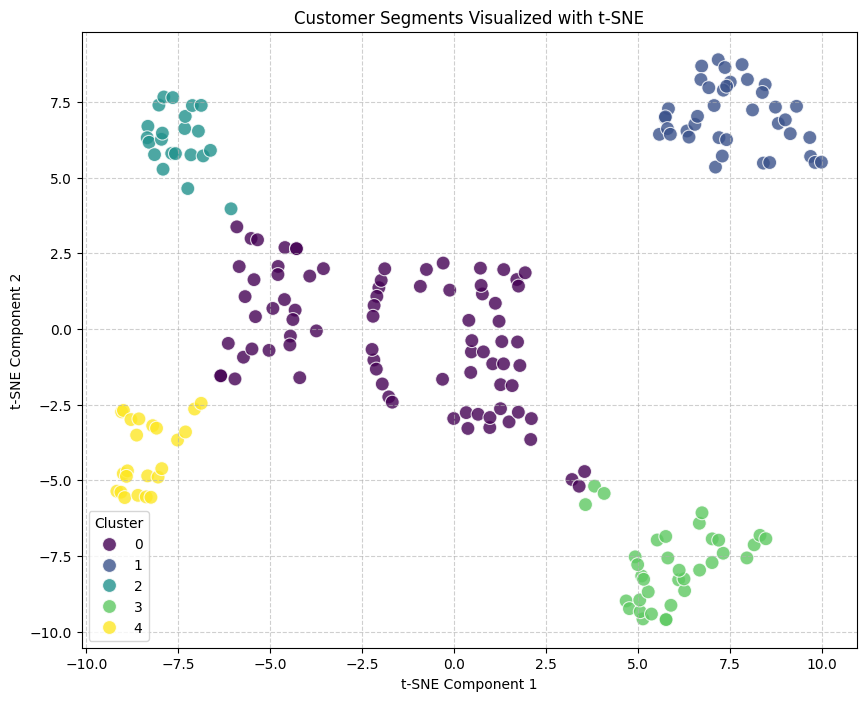

In [11]:
from sklearn.manifold import TSNE

# Prepare data for t-SNE (using the scaled features X_scaled)
# Set n_components to 2 for a 2D visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
X_tsne = tsne.fit_transform(X_scaled)

# Add t-SNE components and cluster labels to a new DataFrame for plotting
tsne_df = pd.DataFrame(data=X_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df['Cluster'] = df['Cluster']

# Visualize the clusters using t-SNE
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    hue='Cluster',
    data=tsne_df,
    palette='viridis',
    s=100,
    alpha=0.8,
    edgecolor='w'
)
plt.title('Customer Segments Visualized with t-SNE')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster')
plt.show()